In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_parquet('../thar_historical_training_data.parquet')
df.head()

,temperature,humidity,wind_speed,wind_dir,precipitation,pressure,cloud_cover,aqi,pm25,pm10,...,is_dust_season,pm_ratio,heat_humidity_index,stagnation_index,aqi_change_rate,aqi_rolling_3h,aqi_rolling_24h,aqi_plus_24h,aqi_plus_48h,aqi_plus_72h
0,26.4,94,3.01,264,0.0,992.8,95,NaN,13.5,29.5,...,0,0.4576,24.82,0.3215,0.0,NaN,NaN,39.0,25.0,25.0
1,26.5,94,3.60,270,0.0,992.9,98,NaN,13.4,30.9,...,0,0.4337,24.91,0.2703,0.0,NaN,NaN,38.0,25.0,25.0
2,26.9,91,4.22,275,0.0,993.6,97,NaN,13.6,33.1,...,0,0.4109,24.48,0.2315,0.0,NaN,NaN,38.0,25.0,25.0
3,27.9,87,4.20,273,0.0,994.0,97,NaN,14.2,38.2,...,0,0.3717,24.27,0.2326,0.0,NaN,NaN,38.0,25.0,25.0
4,29.0,81,3.51,273,0.0,994.0,98,NaN,15.3,42.0,...,0,0.3643,23.49,0.2770,0.0,NaN,NaN,37.0,25.0,26.0


Dataset Inspection

In [2]:
print("Dataset Shape:", df.shape)
print("\n Data Types & Non-Null Counts ")
df.info()

print("\n Missing Values ")
print(df.isnull().sum())

Dataset Shape: (100080, 41)

 Data Types & Non-Null Counts 
<class 'pandas.DataFrame'>
RangeIndex: 100080 entries, 0 to 100079
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   temperature          100080 non-null  float64       
 1   humidity             100080 non-null  int64         
 2   wind_speed           100080 non-null  float64       
 3   wind_dir             100080 non-null  int64         
 4   precipitation        100080 non-null  float64       
 5   pressure             100080 non-null  float64       
 6   cloud_cover          100080 non-null  int64         
 7   aqi                  100008 non-null  float64       
 8   pm25                 100080 non-null  float64       
 9   pm10                 100080 non-null  float64       
 10  no2                  100080 non-null  float64       
 11  o3                   100080 non-null  float64       
 12  co                   10

Feature Droppingg

In [3]:
print("Feature Variances ---")
variances = df.var(numeric_only=True).sort_values()
print(variances)

Feature Variances ---
pm_ratio                   0.051895
stagnation_index           0.144751
is_dust_season             0.179910
is_weekend                 0.204348
is_mine                    0.222224
precipitation              0.295245
day_cos                    0.478431
month_cos                  0.482943
hour_cos                   0.500005
hour_sin                   0.500005
month_sin                  0.515083
day_sin                    0.519209
quarter                    1.298832
wind_speed                 3.659144
weekday                    3.998582
no2                        4.019473
aqi_change_rate            5.743960
so2                       10.229720
month                     12.473798
pressure                  45.874927
heat_humidity_index       46.311995
temperature               47.201421
hour                      47.917145
day                       76.806438
pm25                     122.092682
aqi_rolling_24h          437.716760
aqi_rolling_3h           487.223428
aqi   

Target Distribution

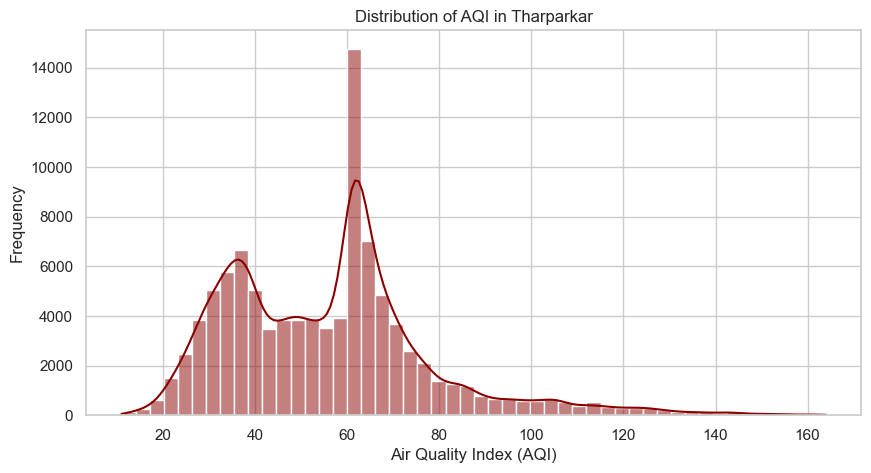

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['aqi'], bins=50, kde=True, color='darkred')
plt.title('Distribution of AQI in Tharparkar')
plt.xlabel('Air Quality Index (AQI)')
plt.ylabel('Frequency')
plt.show()

Feature Correlation Matrix

HeatMap

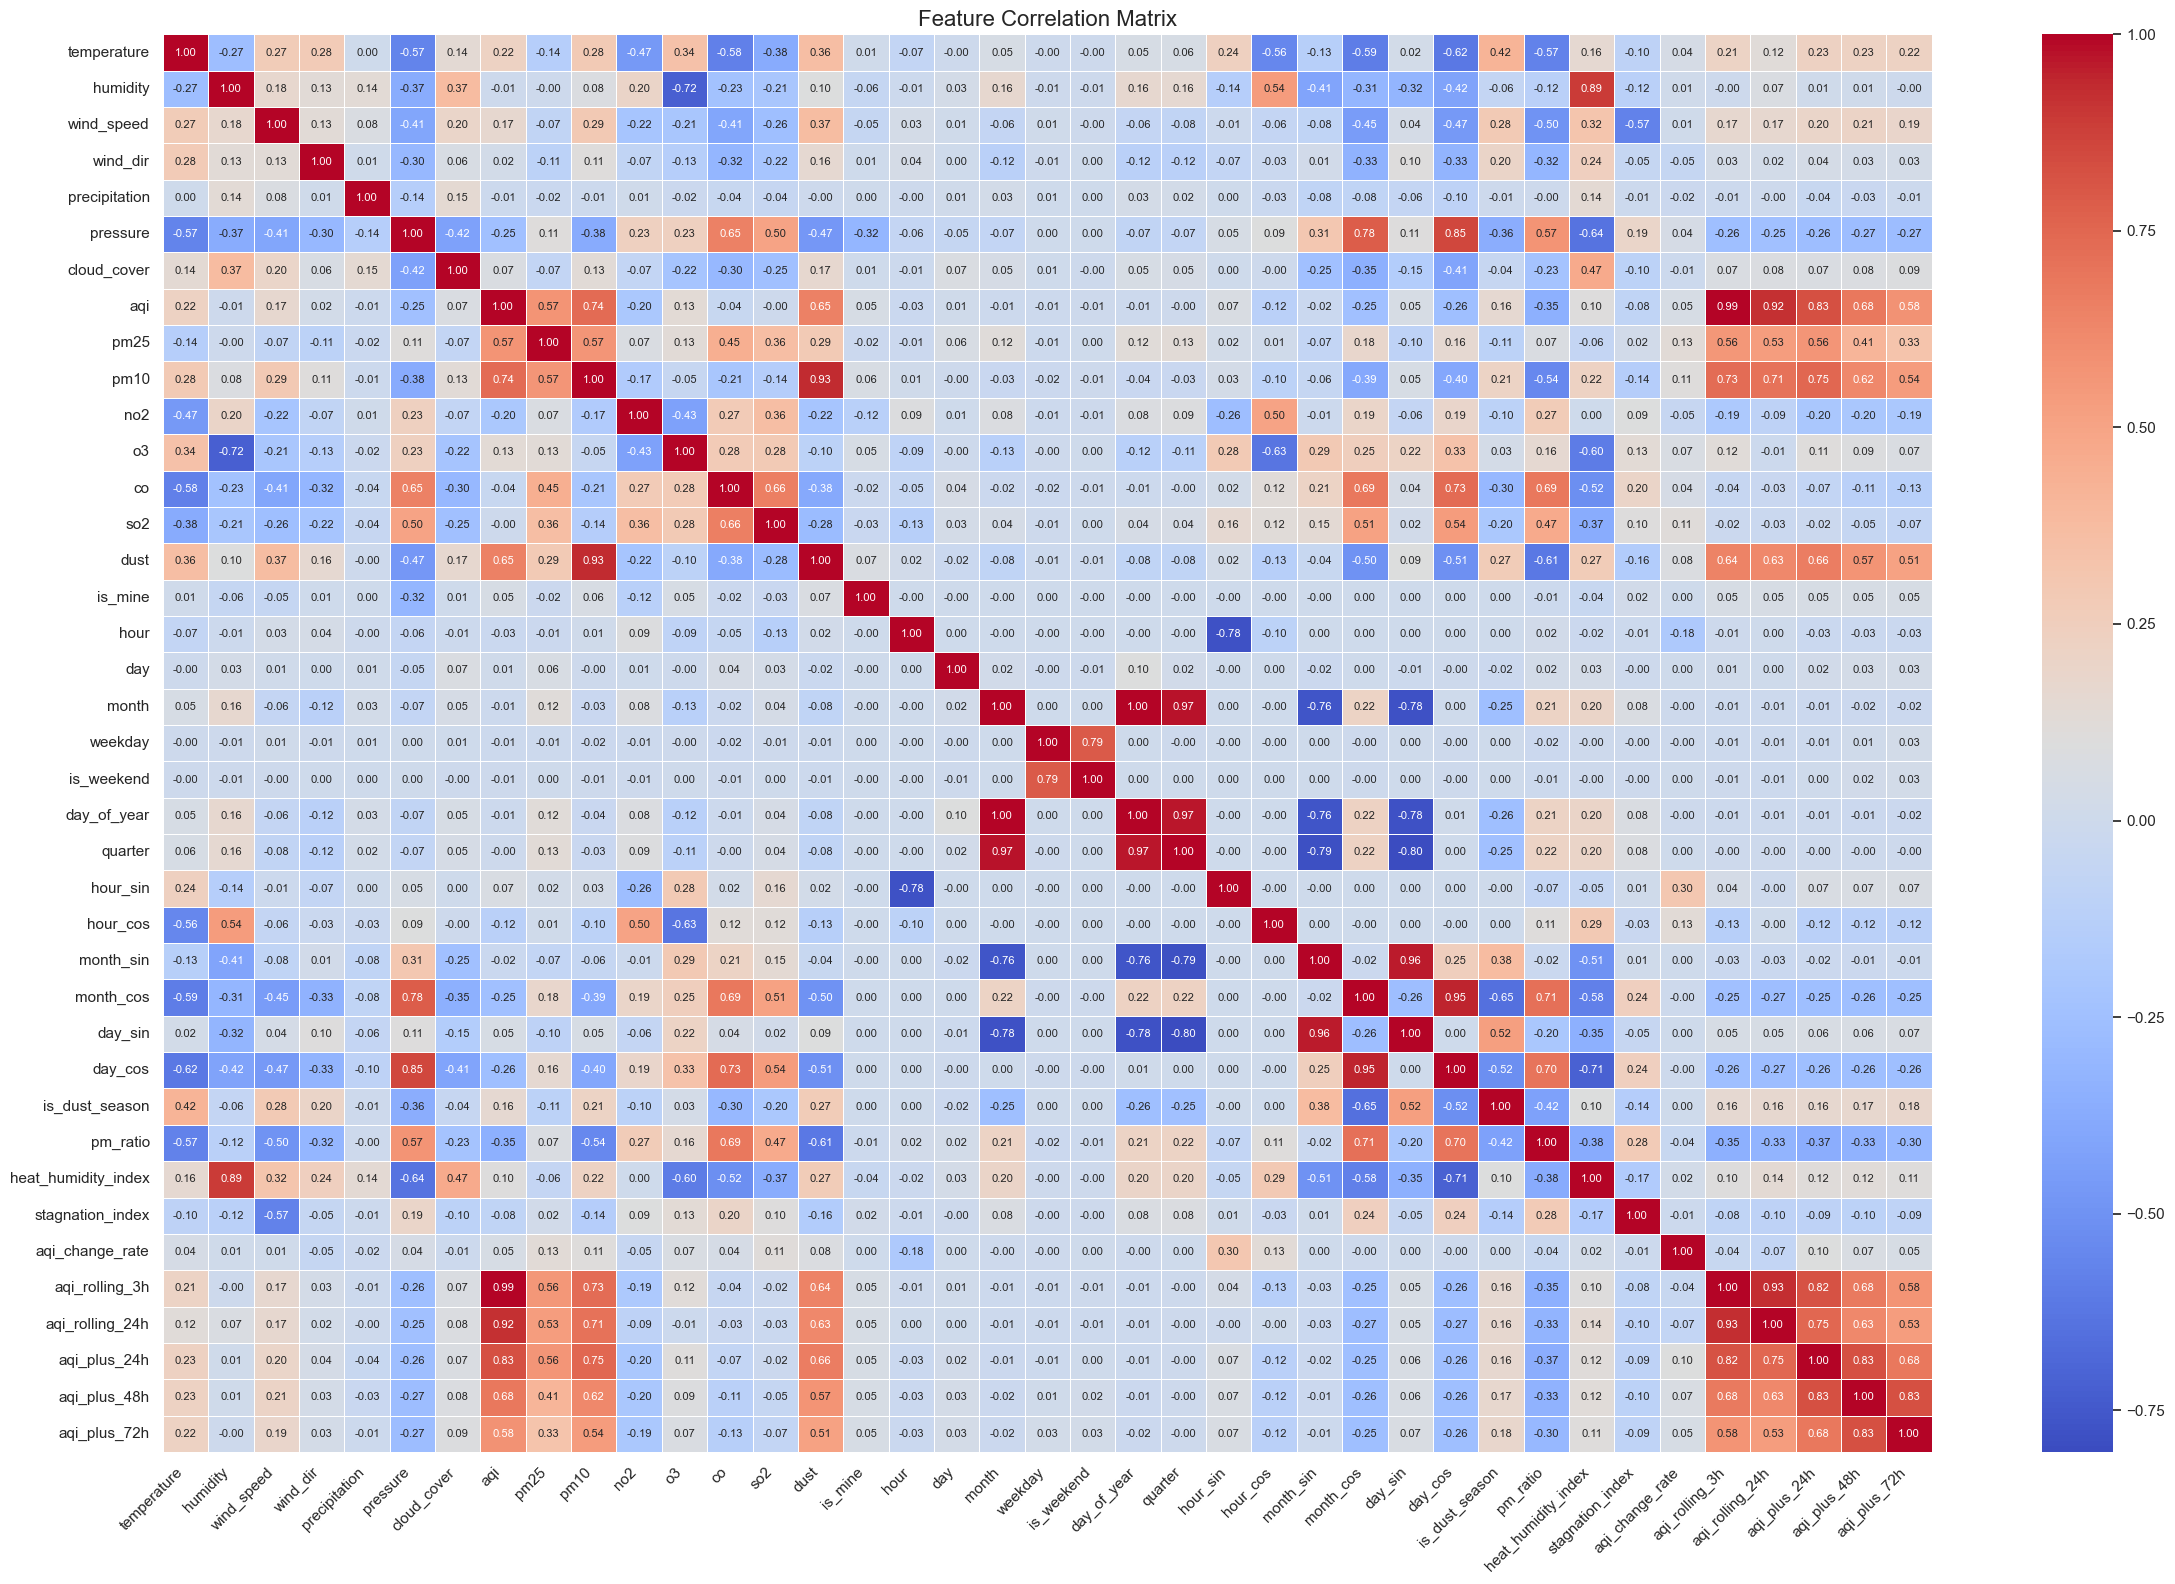

In [8]:
plt.figure(figsize=(24, 16)) # Dramatically increase width and height

# Add annot_kws to shrink the text size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, annot_kws={"size": 8})

plt.xticks(rotation=45, ha='right') # Rotate bottom labels so they don't overlap
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

Target Correlation

C:\Users\user\AppData\Local\Temp\ipykernel_14996\1116587472.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aqi_corr.values, y=aqi_corr.index, palette='coolwarm')


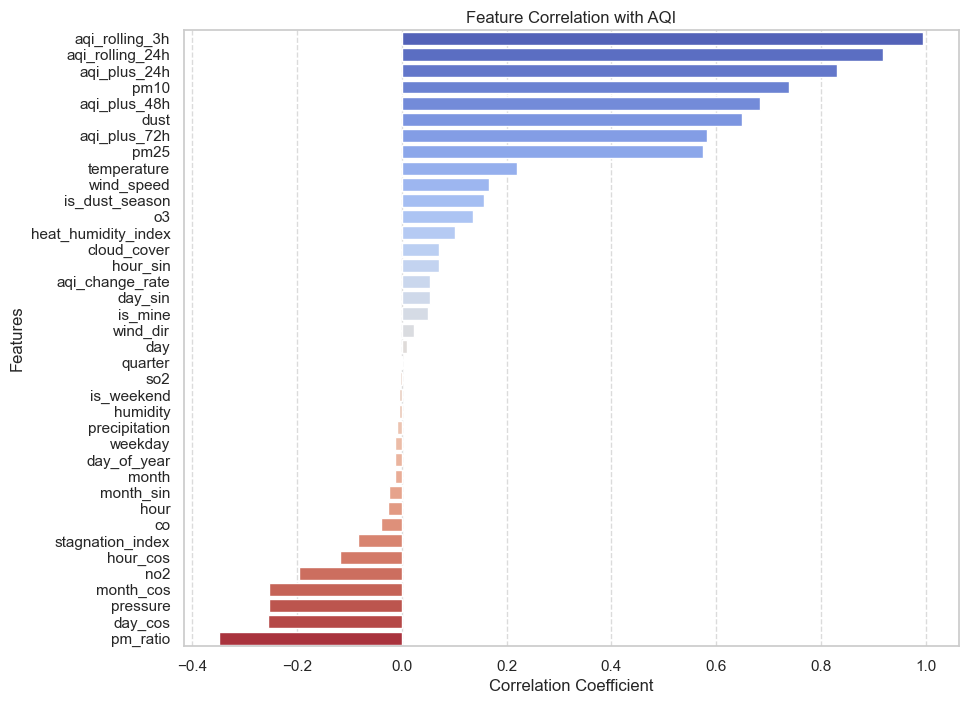

In [7]:
plt.figure(figsize=(10, 8))

# Get correlation of all features with 'aqi', drop 'aqi' itself, and sort
aqi_corr = correlation_matrix['aqi'].drop('aqi').sort_values(ascending=False)

# Plot as a bar chart
sns.barplot(x=aqi_corr.values, y=aqi_corr.index, palette='coolwarm')
plt.title('Feature Correlation with AQI')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Time Series 

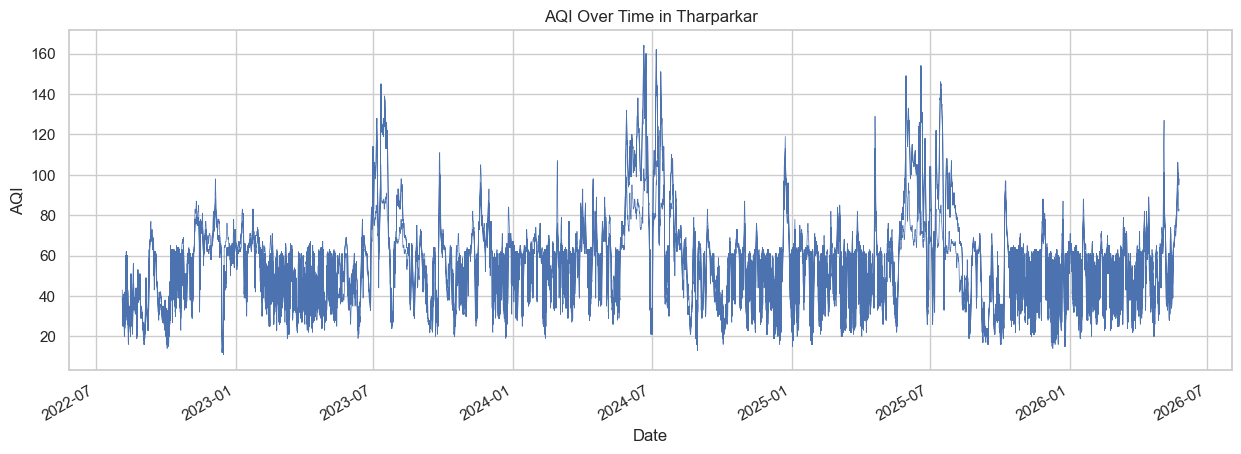

In [6]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df_time = df.set_index('timestamp')
    
    plt.figure(figsize=(15, 5))
    df_time['aqi'].plot(linewidth=0.5)
    plt.title('AQI Over Time in Tharparkar')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.show()
else:
    print("No timestamp column found for time-series plotting.")